<a href="https://colab.research.google.com/github/ryanaxiom/Applied-ML/blob/main/code/Day09_carnegie.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Student Instructions**: Before you begin, click **File > Save a copy in Drive** so you do not lose your work!

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

print(pd.__version__)
print(np.__version__)

url = ("https://raw.githubusercontent.com/ryanaxiom/Applied-ML/main/data/carnegie_data.csv")

carnegie_raw = pd.read_csv(url, encoding="cp1252")
carnegie = carnegie_raw.copy()
carnegie["research"] = carnegie["serd"] + carnegie["nonserd"]
d = carnegie[carnegie["research"].notna()].copy()
d["med_yn"] = (d["medical"] == 1).astype(int)

y = d["research"]
pile = ["fallenr20", "totdeg", "facnum", "stem_rsd", "med_yn"]
model2 = LinearRegression()
model2.fit(d[["fallenr20","med_yn"]], y)

2.2.3
2.1.3


LinearRegression()

In [5]:
d["enroll_x_med"] = d["fallenr20"] * d["med_yn"]
Xi = d[["fallenr20", "med_yn", "enroll_x_med"]]
model_i = LinearRegression()
model_i.fit(Xi,y)
model_i.coef_.round(3),model_i.intercept_.round(1)

(array([4.80500000e+00, 1.93415321e+05, 5.46700000e+00]), np.float64(19434.1))

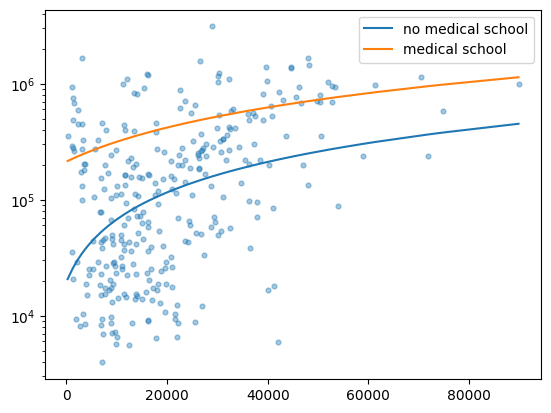

In [9]:
b0, (b1, b2, b3) = model_i.intercept_, model_i.coef_
xs = np.sort(d["fallenr20"])
plt.scatter(d["fallenr20"],y,s=12,alpha=0.4)
plt.plot(xs, b0 + b1*xs, label="no medical school")
plt.plot(xs, (b0+b2) + (b1+b3)*xs, label="medical school")
plt.yscale("log")
plt.legend()

In [10]:
d["log_research"] = np.log(d["research"])
model_log = LinearRegression()
model_log.fit(d[["fallenr20", "med_yn"]], d["log_research"])
model_log.coef_,model_log.intercept_

(array([3.34831268e-05, 1.50815232e+00]), np.float64(10.152838357391978))

In [12]:
estimates = model_log.predict(d[["fallenr20","med_yn"]])
np.corrcoef(d["log_research"], estimates)**2

array([[1.        , 0.42515931],
       [0.42515931, 1.        ]])

In [14]:
b_enroll, b_med = model_log.coef_
np.exp(b_enroll)**1000, np.exp(b_med)

(np.float64(1.0340499958705278), np.float64(4.518374551171006))

In [17]:
pred_log = np.exp(estimates)
pred_raw = model2.predict(d[["fallenr20","med_yn"]])
print(np.sqrt(np.mean((y-pred_log)**2)), np.sqrt(np.mean((y-pred_raw)**2)))
print(np.median(np.abs(y-pred_log)/y), np.median(np.abs(y-pred_raw)/y))

345435.00310341414 314589.93735226564
0.6590024948927695 0.7680917629915993


In [18]:
y.mean(), pred_log.mean()

(np.float64(274039.6589403974), np.float64(176331.0097448582))

In [20]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(d, test_size = .25, random_state=309)
len(train),len(test)

(226, 76)

In [24]:
def rmse(a, b): return np.sqrt(np.mean((a - b)**2))
specs = {"two": ["fallenr20", "med_yn"],
         "trio": ["fallenr20", "med_yn", "stem_rsd"],
         "pile": pile}
for name, cols in specs.items():
    m = LinearRegression()
    m.fit(train[cols], train["research"])
    print(name, "train: ",round(rmse(train["research"], m.predict(train[cols]))),
          ", test: ", round(rmse(test["research"], m.predict(test[cols]))))

two train:  317889 , test:  305751
trio train:  231141 , test:  242540
pile train:  196293 , test:  191636


In [28]:
for seed in [1, 2, 3, 0, 309]:
    tr, te = train_test_split(d, test_size=0.25, random_state=seed)
    m = LinearRegression()
    m.fit(tr[pile], tr["research"])
    print(seed, round(rmse(te["research"], m.predict(te[pile]))))

1 142816
2 300147
3 269769
0 159357
309 191636
